# 02 — Data Preparation, Preprocessing & EDA


Loads all raw datasets, standardises schema, merges, cleans, balances classes,
splits into train/val/test, and runs exploratory data analysis.

**Inputs:**
- `/kaggle/input/` — raw datasets (phishing email, NUS SMS, UCI SMS, job postings, Wikipedia)
- `/kaggle/working/data/synthetic_dataset.csv` — generated by NB01

**Outputs:**
- `scamsense_full_dataset.csv`
- `train.csv`, `val.csv`, `test.csv`
- `reports/figures/` — EDA plots


---
## Section 1: Data Loading & Preparation

### 1.1 Imports

In [54]:
import os
import json
import warnings
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# output directories
BASE_DIR    = "/kaggle/working"
DATA_DIR    = os.path.join(BASE_DIR, "data")
REPORT_DIR  = os.path.join(BASE_DIR, "reports")
FIGURES_DIR = os.path.join(REPORT_DIR, "figures")

for d in [DATA_DIR, REPORT_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

# dataset paths
RAW_SYNTH = "/kaggle/input/datasets/bhoovika/scamscene-raw-dataset/synthetic_dataset.csv"

RAW_PHISH = "/kaggle/input/datasets/naserabdullahalam/phishing-email-dataset/phishing_email.csv"

RAW_UCI = "/kaggle/input/datasets/bhoovika/scamscene-raw-dataset/SMSSpamCollection"

RAW_JOBS = "/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv"

RAW_NUS_EN = "/kaggle/input/datasets/rtatman/the-national-university-of-singapore-sms-corpus/smsCorpus_en_2015.03.09_all.json"

RAW_NUS_ZH = "/kaggle/input/datasets/rtatman/the-national-university-of-singapore-sms-corpus/smsCorpus_zh_2015.03.09.json"

RAW_WIKI_MS = "/kaggle/input/datasets/bhoovika/scamscene-raw-dataset/wiki_ms.csv"
RAW_WIKI_TA = "/kaggle/input/datasets/bhoovika/scamscene-raw-dataset/wiki_ta.csv"
RAW_WIKI_ZH = "/kaggle/input/datasets/bhoovika/scamscene-raw-dataset/wiki_zh.csv"

# split ratios
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42

print("Imports done")
print("DATA_DIR:", DATA_DIR)

Imports done
DATA_DIR: /kaggle/working/data


### 1.2 Load scam sources (label = 1)

In [55]:
scam_frames = []

# synthetic scam data
print("Loading synthetic scam data...")
df_synth = pd.read_csv(RAW_SYNTH, encoding="utf-8-sig")
df_synth = df_synth[["text", "label", "language", "scam_type"]].copy()
df_synth["source"] = "synthetic_spf2025"

scam_frames.append(df_synth)
print(f"  ✓ Synthetic: {len(df_synth):,} rows")

# phishing email dataset
print("Loading Phishing Email Dataset...")
df_phishing = pd.read_csv(
    RAW_PHISH,
    usecols=["text_combined", "label"],
    on_bad_lines="skip"
)

df_phishing.columns = ["text", "label"]
df_phishing["language"] = "en"
df_phishing["source"] = "phishing_email"

df_phishing_scam = df_phishing[df_phishing["label"] == 1].copy()
df_phishing_ham = df_phishing[df_phishing["label"] == 0].copy()

scam_frames.append(df_phishing_scam)

print(f"  ✓ Phishing scam rows: {len(df_phishing_scam):,}")
print(f"  ✓ Phishing ham rows:  {len(df_phishing_ham):,} (added later)")

# UCI SMS spam
print("Loading UCI SMS spam rows...")
df_uci = pd.read_csv(
    RAW_UCI,
    sep="\t",
    header=None,
    names=["label_str", "text"],
    on_bad_lines="skip"
)

df_uci_spam = df_uci[df_uci["label_str"] == "spam"].copy()
df_uci_spam["label"] = 1
df_uci_spam["language"] = "en"
df_uci_spam["source"] = "uci_sms_spam"

df_uci_spam = df_uci_spam[["text", "label", "language", "source"]]

scam_frames.append(df_uci_spam)

print(f"  ✓ UCI SMS spam: {len(df_uci_spam):,} rows")

# fake job postings
print("Loading fake job postings...")

df_jobs = pd.read_csv(
    RAW_JOBS,
    on_bad_lines="skip"
)

df_jobs["text"] = (
    df_jobs["title"].fillna("") + " " +
    df_jobs["description"].fillna("")
).str.strip()

df_jobs_scam = df_jobs[df_jobs["fraudulent"] == 1].copy()

df_jobs_scam["label"] = 1
df_jobs_scam["language"] = "en"
df_jobs_scam["source"] = "job_postings_fake"

df_jobs_scam = df_jobs_scam[
    ["text", "label", "language", "source"]
]

scam_frames.append(df_jobs_scam)

print(f"  ✓ Fake job postings: {len(df_jobs_scam):,} rows")

df_scam = pd.concat(scam_frames, ignore_index=True)

print(f"\nTotal scam rows (before cleaning): {len(df_scam):,}")
print(df_scam["source"].value_counts())

Loading synthetic scam data...
  ✓ Synthetic: 23,255 rows
Loading Phishing Email Dataset...
  ✓ Phishing scam rows: 42,891
  ✓ Phishing ham rows:  39,595 (added later)
Loading UCI SMS spam rows...
  ✓ UCI SMS spam: 747 rows
Loading fake job postings...
  ✓ Fake job postings: 866 rows

Total scam rows (before cleaning): 67,759
source
phishing_email       42891
synthetic_spf2025    23255
job_postings_fake      866
uci_sms_spam           747
Name: count, dtype: int64


### 1.3 Load ham sources (label = 0)

In [56]:
ham_frames = []

# phishing email ham
print("Loading phishing email ham rows...")

ham_frames.append(df_phishing_ham)

print(f"Phishing ham: {len(df_phishing_ham):,} rows")

# UCI SMS ham
print("Loading UCI SMS ham rows...")

df_uci_ham = df_uci[df_uci["label_str"] == "ham"].copy()

df_uci_ham["label"] = 0
df_uci_ham["language"] = "en"
df_uci_ham["source"] = "uci_sms_ham"

df_uci_ham = df_uci_ham[
    ["text", "label", "language", "source"]
]

ham_frames.append(df_uci_ham)

print(f"  ✓ UCI SMS ham: {len(df_uci_ham):,} rows")

# NUS SMS corpus
print("Loading NUS SMS Corpus...")

NUS_FILES = [
    (RAW_NUS_EN, "singlish"),
    (RAW_NUS_ZH, "zh")
]

for fpath, lang in NUS_FILES:

    with open(fpath, encoding="utf-8") as f:
        raw_json = json.load(f)

    messages = raw_json["smsCorpus"]["message"]

    texts = [
        m["text"]["$"]
        for m in messages
        if "$" in m.get("text", {})
    ]

    df_nus = pd.DataFrame({
        "text": texts,
        "label": 0,
        "language": lang,
        "source": "nus_sms"
    })

    ham_frames.append(df_nus)

    print(f"  ✓ NUS SMS ({lang}): {len(df_nus):,} rows")

# real job postings
print("Loading real job postings...")

df_jobs_ham = df_jobs[df_jobs["fraudulent"] == 0].copy()

df_jobs_ham["text"] = (
    df_jobs_ham["title"].fillna("") + " " +
    df_jobs_ham["description"].fillna("")
).str.strip()

df_jobs_ham["label"] = 0
df_jobs_ham["language"] = "en"
df_jobs_ham["source"] = "job_postings_real"

df_jobs_ham = df_jobs_ham[
    ["text", "label", "language", "source"]
]

ham_frames.append(df_jobs_ham)

print(f"  ✓ Real job postings: {len(df_jobs_ham):,} rows")

# Wikipedia multilingual ham
print("Loading Wikipedia multilingual ham...")

WIKI_FILES = [
    (RAW_WIKI_MS, "ms"),
    (RAW_WIKI_TA, "ta"),
    (RAW_WIKI_ZH, "zh")
]

for fpath, lang in WIKI_FILES:

    df_wiki = pd.read_csv(
        fpath,
        usecols=["text"],
        on_bad_lines="skip"
    )

    df_wiki["label"] = 0
    df_wiki["language"] = lang
    df_wiki["source"] = f"wikipedia_{lang}"

    ham_frames.append(df_wiki)

    print(f"  ✓ Wikipedia {lang}: {len(df_wiki):,} rows")

df_ham = pd.concat(ham_frames, ignore_index=True)

print(f"\nTotal ham rows (before cleaning): {len(df_ham):,}")
print(df_ham["source"].value_counts())

Loading phishing email ham rows...
Phishing ham: 39,595 rows
Loading UCI SMS ham rows...
  ✓ UCI SMS ham: 4,825 rows
Loading NUS SMS Corpus...
  ✓ NUS SMS (singlish): 55,835 rows
  ✓ NUS SMS (zh): 31,460 rows
Loading real job postings...
  ✓ Real job postings: 17,014 rows
Loading Wikipedia multilingual ham...
  ✓ Wikipedia ms: 5,000 rows
  ✓ Wikipedia ta: 5,000 rows
  ✓ Wikipedia zh: 5,000 rows

Total ham rows (before cleaning): 163,729
source
nus_sms              87295
phishing_email       39595
job_postings_real    17014
wikipedia_ta          5000
wikipedia_ms          5000
wikipedia_zh          5000
uci_sms_ham           4825
Name: count, dtype: int64


### 1.4 Merge and schema standardisation

In [57]:
from IPython.display import display

# merge all
df = pd.concat([df_scam, df_ham], ignore_index=True)
print(f"Raw merged: {df.shape}")

# standardise types
df["text"]     = df["text"].astype(str)
df["label"]    = df["label"].astype(int)
df["language"] = df["language"].astype(str)
df["source"]   = df["source"].astype(str)

# fill missing scam_type from source
if "scam_type" not in df.columns:
    df["scam_type"] = None

def assign_scam_type(row):
    # if already labelled (scam rows from SPF synthetic data), keep it
    if pd.notna(row["scam_type"]):
        return row["scam_type"]
    
    s = str(row["source"]).lower()
    
    # ham rows — check label first to avoid keyword mismatch
    if row["label"] == 0:
        if "nus" in s:
            return "legitimate_sms"
        if "wiki" in s:
            return "legitimate_text"
        if "job" in s:
            return "legitimate_job"   
        if "phishing" in s:
            return "legitimate_email"    
        if "uci" in s:
            return "legitimate_sms"  
        return "legitimate_other"
    
    # scam rows from external sources
    if "phishing" in s:
        return "phishing_email"
    if "uci" in s:
        return "sms_spam"
    if "job" in s:
        return "fake_job"
    
    return "legitimate_other"

df["scam_type"] = df.apply(assign_scam_type, axis=1)

# Sanity check: no ham row should have a scam scam_type
scam_types_for_scams = {
    "phishing_email", "sms_spam", "fake_job", "job_scam",
    "phishing", "rental", "investment", "charity",
    "parcel_delivery", "fake_friend", "prize",
    "bank_impersonation", "loan", "ecommerce",
    "government_impersonation"
}
bad_rows = df[(df["label"] == 0) & (df["scam_type"].isin(scam_types_for_scams))]
print(f"\nHam rows with scam scam_type (should be 0): {len(bad_rows)}")
if len(bad_rows) > 0:
    print(bad_rows["source"].value_counts())

# Distribution
print("\n=== SCAM TYPE DISTRIBUTION ===")
print(df["scam_type"].value_counts())
print(f"\nNull scam_type remaining: {df['scam_type'].isna().sum()}")

print("\nSchema:")
display(df.dtypes.to_frame("dtype"))

print("\nSample row from each language:")
sample_df = (
    df.groupby("language", group_keys=False)
      .apply(lambda x: x.sample(1, random_state=42))
      .reset_index(drop=True)
)
display(sample_df[["text", "label", "language", "scam_type", "source"]])

Raw merged: (231488, 5)

Ham rows with scam scam_type (should be 0): 0

=== SCAM TYPE DISTRIBUTION ===
scam_type
legitimate_sms              92120
phishing_email              42891
legitimate_email            39595
legitimate_job              17014
legitimate_text             15000
job_scam                     2362
phishing                     2114
rental                       2040
investment                   2033
charity                      2015
parcel_delivery              1994
fake_friend                  1981
prize                        1969
bank_impersonation           1925
loan                         1901
ecommerce                    1853
government_impersonation     1068
fake_job                      866
sms_spam                      747
Name: count, dtype: int64

Null scam_type remaining: 0

Schema:


,dtype
text,object
label,int64
language,object
scam_type,object
source,object



Sample row from each language:


,text,label,language,scam_type,source
0,Creative Web Designer (Frontend/UX/Wordpress) ...,0,en,legitimate_job,job_postings_real
1,Pokok Merawan Meranti merupakan sejenis tumbuh...,0,ms,legitimate_text,wikipedia_ms
2,We do??? I thought the team leader needs to demo,0,singlish,legitimate_sms,nus_sms
3,உங்கள் தொகுப்பு வழங்கப்படாது. SGD 300 கட்டணம் ...,1,ta,parcel_delivery,synthetic_spf2025
4,<#> 块，算我请你吧～:-P 呵呵，没冒犯呀～其实我应该多谢关心呢～;-),0,zh,legitimate_sms,nus_sms


### 1.5 Basic checks

In [58]:
# Sanity check: scam rows should never have null scam_type
scam_null_scamtype = df[(df["label"] == 1) & (df["scam_type"].isna())]
print(f"Scam rows with null scam_type: {len(scam_null_scamtype)}")

Scam rows with null scam_type: 0


In [59]:
print("=== NULL COUNTS ===")
print(df.isnull().sum())
print()
print("=== LABEL DISTRIBUTION ===")
print(df["label"].value_counts())
print()
print("=== LANGUAGE DISTRIBUTION ===")
print(df["language"].value_counts())
print()
print("=== ONE SAMPLE PER LANGUAGE ===")
for lang in df["language"].unique():
    sample = df[df["language"] == lang]["text"].iloc[0]
    print(f"[{lang}] {sample[:120]}")
    print()


=== NULL COUNTS ===
text         0
label        0
language     0
scam_type    0
source       0
dtype: int64

=== LABEL DISTRIBUTION ===
label
0    163729
1     67759
Name: count, dtype: int64

=== LANGUAGE DISTRIBUTION ===
language
en          110938
singlish     59539
zh           41452
ms            9831
ta            9728
Name: count, dtype: int64

=== ONE SAMPLE PER LANGUAGE ===
[zh] 国际航空航天局需要您的文件进行验证.您的帐户将被终止.

[singlish] Got fund movement at 3am on your Maybank account sia, faster check.

[en] Unauthorised transfer on your Citibank account. Respond within 24 hours.

[ms] Pekerjaan dalam talian tersedia. SGD 750 per sesi pembayaran dijamin. Hubungi sokongan segera.

[ta] பகுதி நேர ஆன்லைன் விமர்சகர் அவசரமாக தேவை. ஒரு மார்க்கத்திற்கு 2000 SGD சம்பாதிக்கவும். 24 மணி நேரத்திற்குள் பதிலளிக்கவும



---
## Section 2: Preprocessing

### 2.1 Missing values, short texts, duplicates

In [60]:
# drop nulls
before = len(df)
df = df.dropna(subset=["text"])
print(f"Dropped nulls: {before - len(df):,}")

# strip whitespace
df["text"] = df["text"].str.strip()

# drop very short texts (< 5 chars — encoding artifacts)
before = len(df)
df = df[df["text"].str.len() >= 5]
print(f"Dropped short texts: {before - len(df):,}")

# drop literal 'nan' strings
before = len(df)
df = df[df["text"].str.lower() != "nan"]
print(f"Dropped nan strings: {before - len(df):,}")

# deduplicate on (text, language)
before = len(df)
df = df.drop_duplicates(subset=["text", "language"]).reset_index(drop=True)
print(f"Dropped duplicates:  {before - len(df):,}")

print(f"\nClean shape: {df.shape}")


Dropped nulls: 0
Dropped short texts: 6,944
Dropped nan strings: 0
Dropped duplicates:  9,580

Clean shape: (214964, 5)


### 2.2 Label check

In [61]:
print("Label values:", df["label"].unique())
assert set(df["label"].unique()).issubset({0, 1}), "unexpected label values"
print("Label check passed")
print(df["label"].value_counts())


Label values: [1 0]
Label check passed
label
0    147555
1     67409
Name: count, dtype: int64


### 2.3 Language verification

In [62]:
print("Languages present:", df["language"].unique().tolist())
print()
print("Per-language label breakdown:")
print(df.groupby(["language", "label"]).size().unstack(fill_value=0))


Languages present: ['zh', 'singlish', 'en', 'ms', 'ta']

Per-language label breakdown:
label         0      1
language              
en        58765  49155
ms         4974   4831
singlish  47957   3704
ta         4997   4728
zh        30862   4991


### 2.4 Scam type mapping

In [63]:
print("Scam types (scam rows only):")
print(df[df["label"] == 1]["scam_type"].value_counts())


Scam types (scam rows only):
scam_type
phishing_email              42841
job_scam                     2362
phishing                     2114
rental                       2040
investment                   2033
charity                      2015
parcel_delivery              1994
fake_friend                  1981
prize                        1969
bank_impersonation           1924
loan                         1901
ecommerce                    1853
government_impersonation     1068
fake_job                      672
sms_spam                      642
Name: count, dtype: int64


### 2.5 Class balancing (per-language undersampling)

In [64]:
# undersample ham to match scam count per language
# rationale: prevents English ham from dominating; cleaner per-class metrics
balanced = []
for lang in df["language"].unique():
    sub = df[df["language"] == lang]
    scam_n = (sub["label"] == 1).sum()
    ham_n  = (sub["label"] == 0).sum()
    df_s = sub[sub["label"] == 1]
    df_h = sub[sub["label"] == 0]
    if ham_n > scam_n:
        df_h = df_h.sample(n=scam_n, random_state=RANDOM_STATE)
        print(f"{lang}: scam={scam_n:,} | ham undersampled {ham_n:,} -> {scam_n:,}")
    else:
        print(f"{lang}: scam={scam_n:,} | ham={ham_n:,} (keeping all ham)")
    balanced.extend([df_s, df_h])

df_balanced = pd.concat(balanced, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\nBalanced shape: {df_balanced.shape}")
print(df_balanced["label"].value_counts())


zh: scam=4,991 | ham undersampled 30,862 -> 4,991
singlish: scam=3,704 | ham undersampled 47,957 -> 3,704
en: scam=49,155 | ham undersampled 58,765 -> 49,155
ms: scam=4,831 | ham undersampled 4,974 -> 4,831
ta: scam=4,728 | ham undersampled 4,997 -> 4,728

Balanced shape: (134818, 5)
label
0    67409
1    67409
Name: count, dtype: int64


### 2.6 Train / val / test split (70 / 15 / 15)

In [65]:
# stratify on label + language combined key
df_balanced["strat_key"] = df_balanced["label"].astype(str) + "_" + df_balanced["language"]

# drop tiny strat groups (< 2 samples)
key_counts = df_balanced["strat_key"].value_counts()
valid_keys = key_counts[key_counts >= 2].index
df_balanced = df_balanced[df_balanced["strat_key"].isin(valid_keys)].reset_index(drop=True)

# split
train_df, temp_df = train_test_split(
    df_balanced,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df_balanced["strat_key"],
    random_state=RANDOM_STATE,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["strat_key"],
    random_state=RANDOM_STATE,
)

for df_ in [train_df, val_df, test_df]:
    df_.drop(columns=["strat_key"], inplace=True)

total = len(df_balanced)
print(f"Train: {len(train_df):,} ({len(train_df)/total*100:.1f}%)")
print(f"Val:   {len(val_df):,}   ({len(val_df)/total*100:.1f}%)")
print(f"Test:  {len(test_df):,}  ({len(test_df)/total*100:.1f}%)")

print("\nLabel balance per split:")
for name, df_ in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    c = df_["label"].value_counts(normalize=True).round(3)
    print(f"  {name}: scam={c.get(1,0):.3f}  ham={c.get(0,0):.3f}")


Train: 94,372 (70.0%)
Val:   20,223   (15.0%)
Test:  20,223  (15.0%)

Label balance per split:
  Train: scam=0.500  ham=0.500
  Val: scam=0.500  ham=0.500
  Test: scam=0.500  ham=0.500


### 2.7 Save outputs

In [66]:
df_balanced.to_csv(os.path.join(DATA_DIR, "scamsense_full_dataset.csv"), index=False, encoding="utf-8-sig")
train_df.to_csv(   os.path.join(DATA_DIR, "train.csv"), index=False, encoding="utf-8-sig")
val_df.to_csv(     os.path.join(DATA_DIR, "val.csv"),   index=False, encoding="utf-8-sig")
test_df.to_csv(    os.path.join(DATA_DIR, "test.csv"),  index=False, encoding="utf-8-sig")

for fname in ["scamsense_full_dataset.csv", "train.csv", "val.csv", "test.csv"]:
    p = os.path.join(DATA_DIR, fname)
    print(f"  saved {fname}  ({os.path.getsize(p)/1e6:.1f} MB)")


  saved scamsense_full_dataset.csv  (202.1 MB)
  saved train.csv  (136.1 MB)
  saved val.csv  (30.0 MB)
  saved test.csv  (35.3 MB)


---
## Section 3: EDA

### 3.0 Plot config

In [67]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
})

PALETTE = {
    "en":       "#2196F3",
    "singlish": "#FF9800",
    "ms":       "#4CAF50",
    "ta":       "#9C27B0",
    "zh":       "#F44336",
}
LABEL_COLORS = {0: "#43A047", 1: "#E53935"}   # ham=green  scam=red

FIG_DIR = Path("eda_plots")
FIG_DIR.mkdir(exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    print(f"✓ {name}.png")

# ── load dataset ─────────────────────────────────────────────────────────────
INPUT_DIR = "/kaggle/working/data/"
df = pd.read_csv(f"{INPUT_DIR}/scamsense_full_dataset.csv")
if "strat_key" in df.columns:
    df = df.drop(columns=["strat_key"])
if "scam_type" not in df.columns:
    df["scam_type"] = None
df["char_len"]   = df["text"].astype(str).str.len()
df["word_count"] = df["text"].astype(str).str.split().str.len()
print(f"Dataset loaded: {df.shape}")

Dataset loaded: (134818, 7)


### 3.1 Class distribution

✓ 01_class_distribution.png


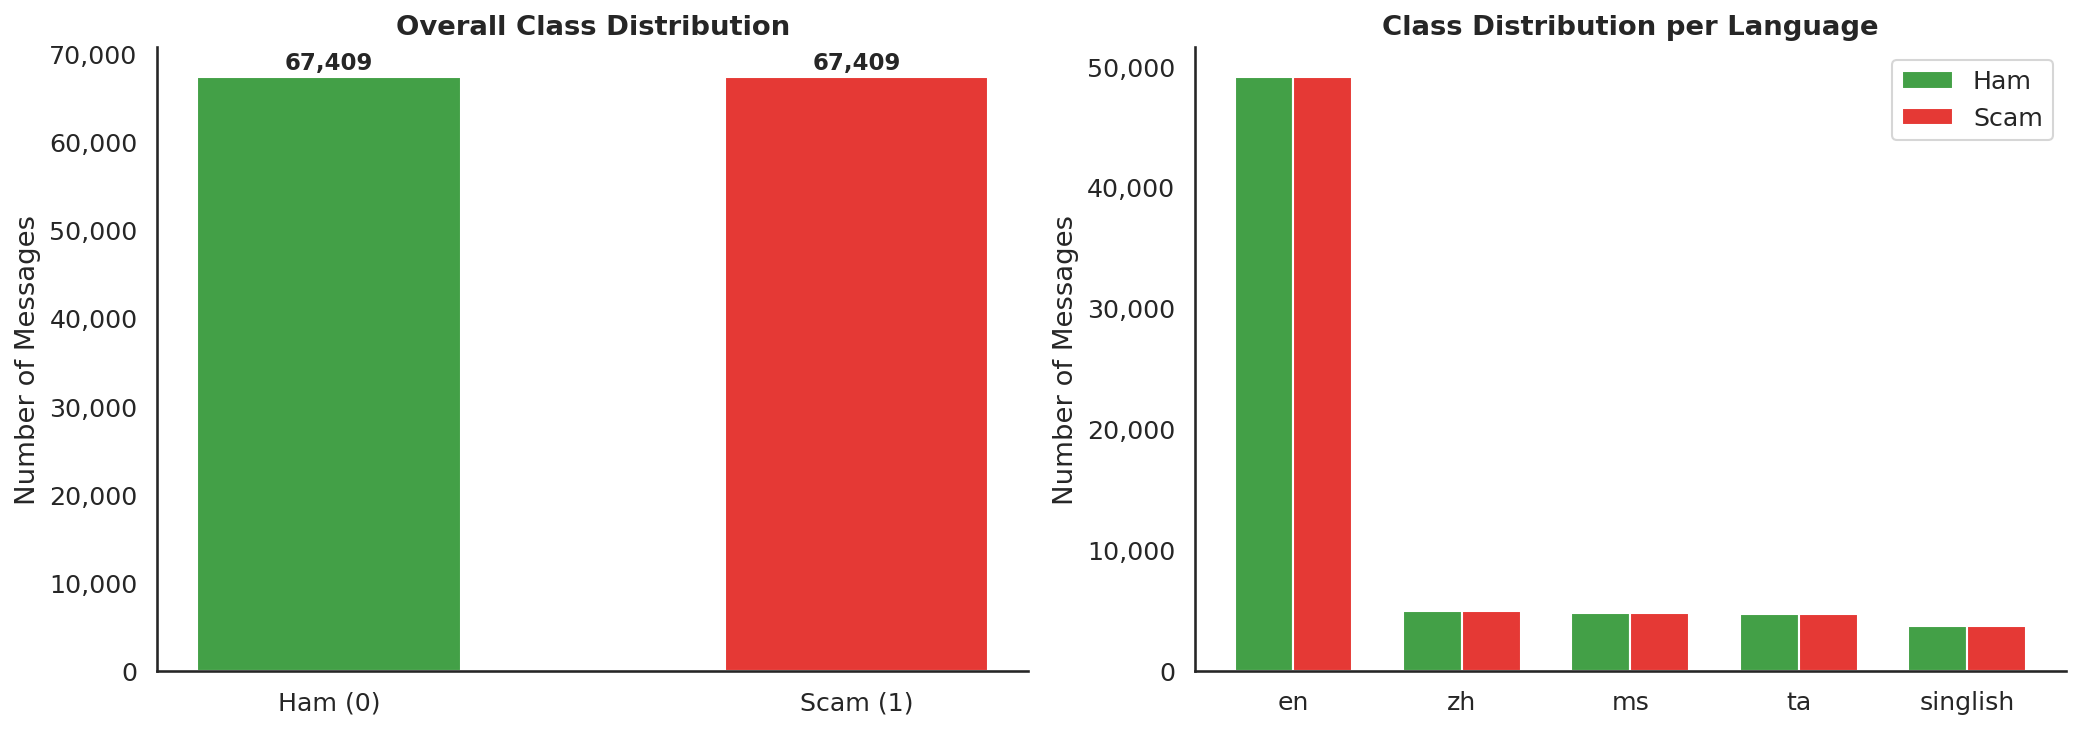

In [68]:
# ── plot 01 · overall & per-language class distribution ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# overall
ax = axes[0]
counts = df["label"].value_counts().sort_index()
bars = ax.bar(["Ham (0)", "Scam (1)"], counts.values,
              color=[LABEL_COLORS[0], LABEL_COLORS[1]], width=0.5, edgecolor="white")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Overall Class Distribution", fontweight="bold")
ax.set_ylabel("Number of Messages")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# per language
ax = axes[1]
lang_label = df.groupby(["language", "label"]).size().unstack(fill_value=0).reindex(columns=[0, 1])
lang_order = lang_label.sum(axis=1).sort_values(ascending=False).index
lang_label = lang_label.loc[lang_order]
x = range(len(lang_label))
w = 0.35
ax.bar([i - w/2 for i in x], lang_label[0], width=w, label="Ham",  color=LABEL_COLORS[0], edgecolor="white")
ax.bar([i + w/2 for i in x], lang_label[1], width=w, label="Scam", color=LABEL_COLORS[1], edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(lang_label.index)
ax.set_title("Class Distribution per Language", fontweight="bold")
ax.set_ylabel("Number of Messages")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
save(fig, "01_class_distribution")
plt.show()

### 3.2 Scam Type Breakdown

✓ 02_scam_type_distribution.png


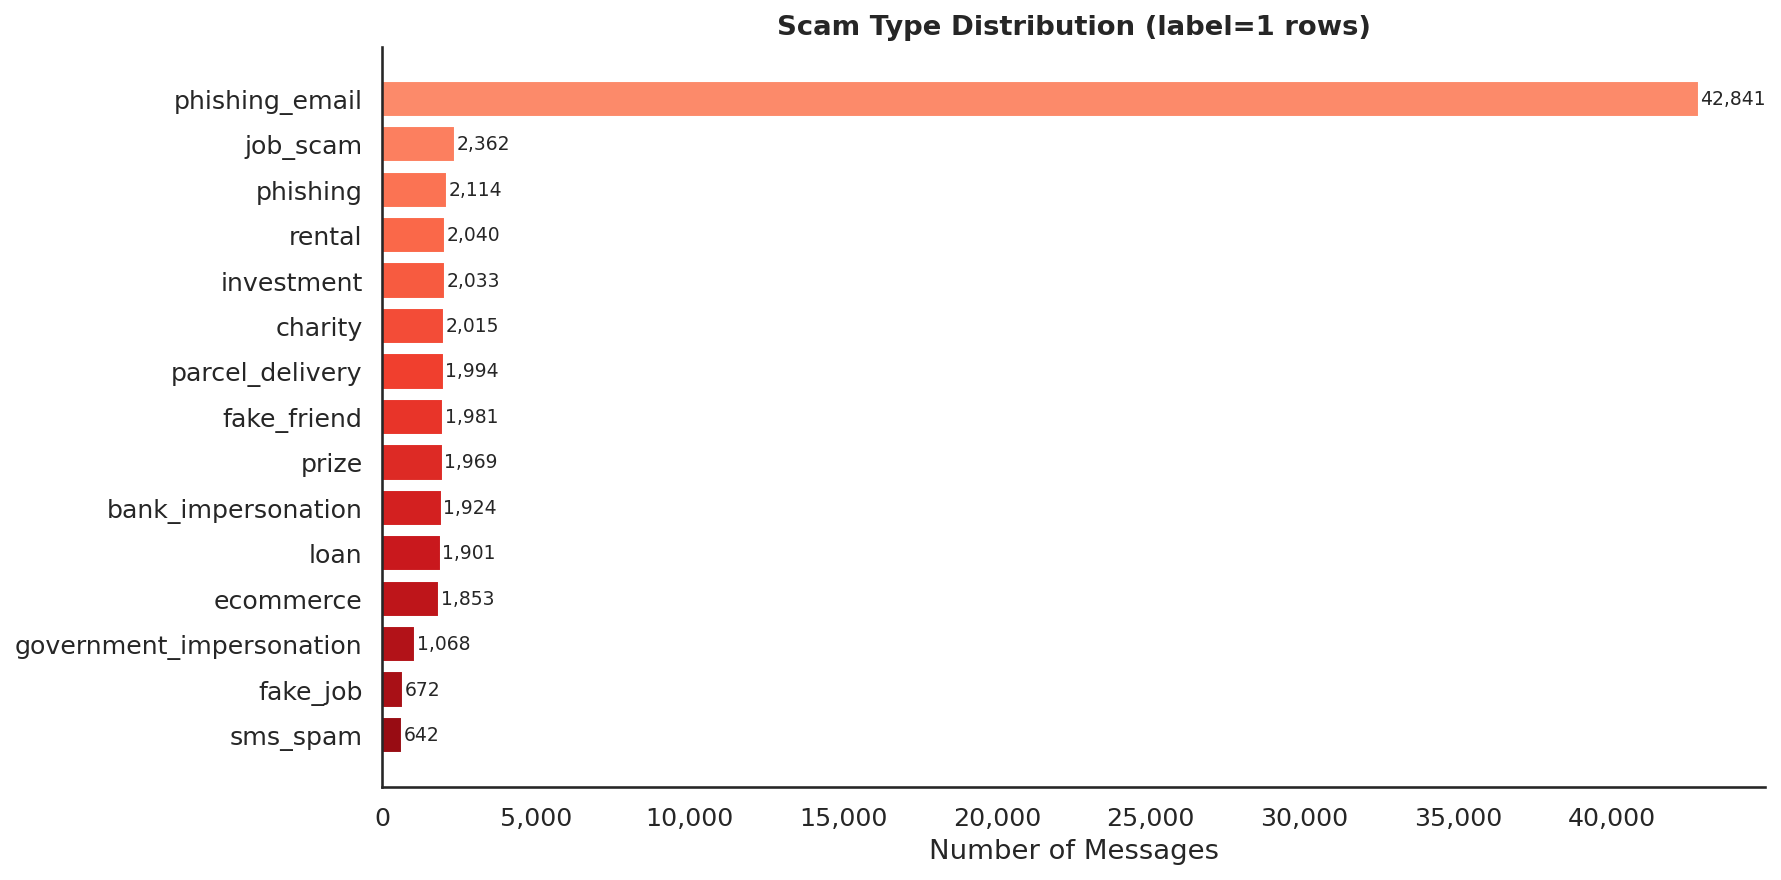

In [69]:
# ── plot 02 · scam type distribution (label=1 rows) ──────────────────────────
df["scam_type_filled"] = df["scam_type"].fillna(
    df["source"].map(lambda s: (
        "phishing_email" if "phishing" in str(s) else
        "sms_spam"       if "uci"      in str(s) else
        "fake_job"       if "job"      in str(s) else
        "ham"
    ))
)

scam_counts = df[df["label"] == 1]["scam_type_filled"].value_counts()
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(scam_counts)))
bars = ax.barh(scam_counts.index, scam_counts.values, color=colors, edgecolor="white")
for bar, val in zip(bars, scam_counts.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
ax.set_xlabel("Number of Messages")
ax.set_title("Scam Type Distribution (label=1 rows)", fontweight="bold")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
save(fig, "02_scam_type_distribution")
plt.show()

### 3.3 Message Length Analysis

✓ 03_message_length.png


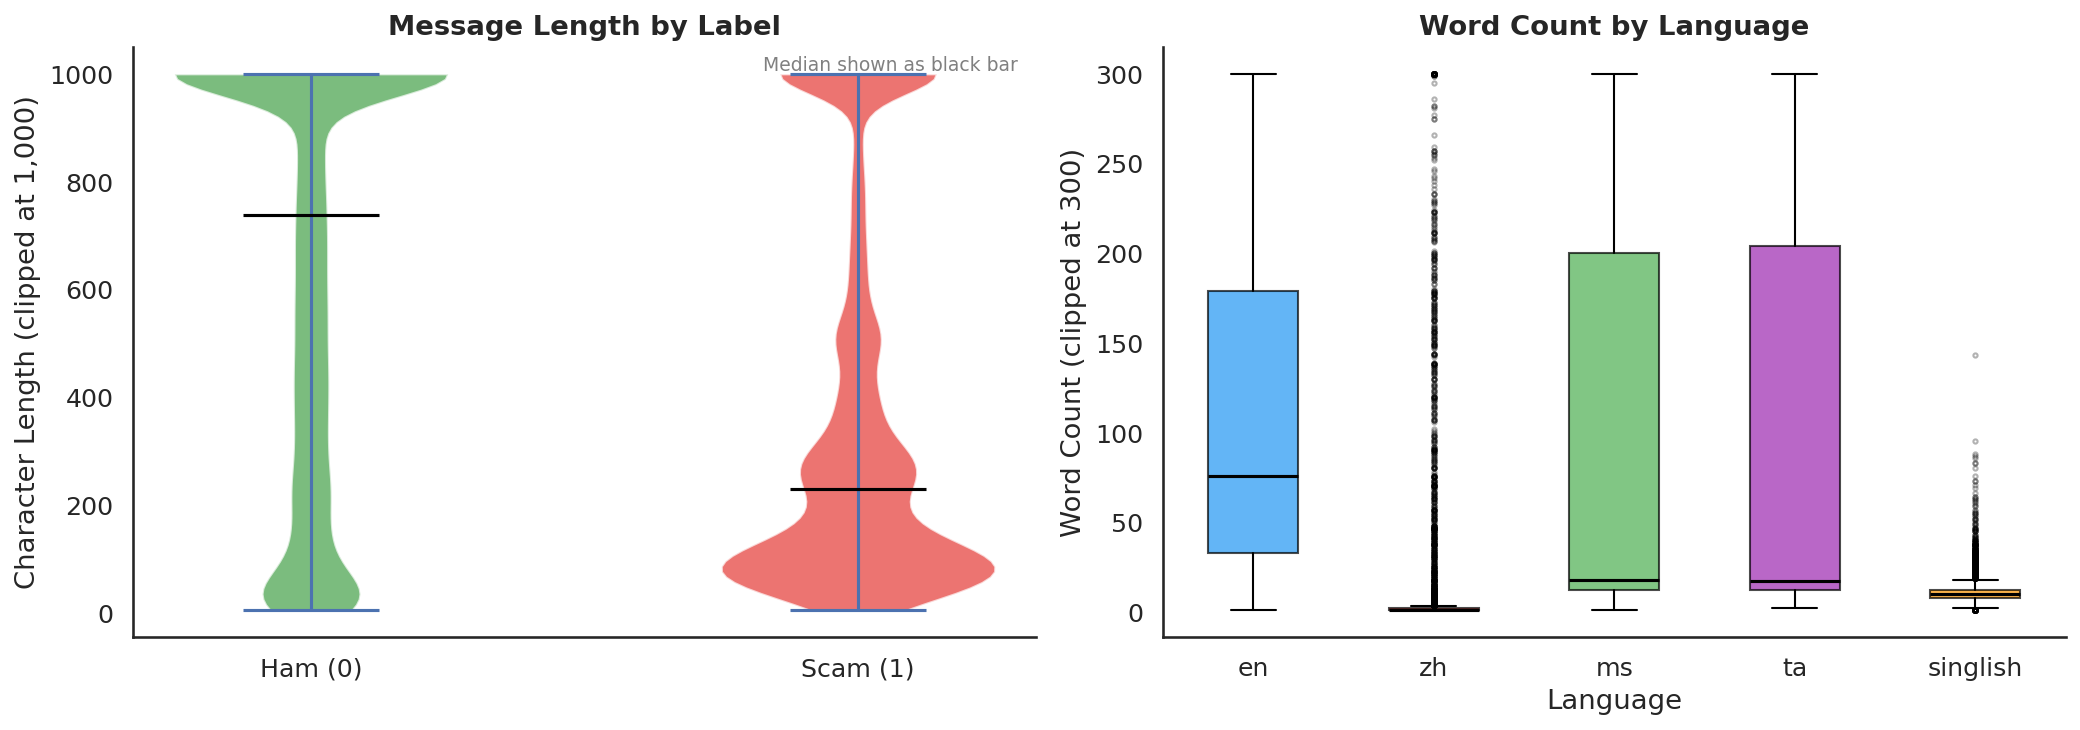


Message length stats:
      char_len                                                         \
         count    mean      std  min    25%    50%     75%        max   
label                                                                   
0      67409.0  1639.7   4179.4  5.0  234.0  738.0  1550.0   160318.0   
1      67409.0   713.0  16911.7  6.0   90.0  230.0   536.0  4279526.0   

      word_count                                                  
           count   mean    std  min   25%   50%    75%       max  
label                                                             
0        67409.0  209.0  523.6  1.0  34.0  99.0  207.0   23359.0  
1        67409.0   82.4  477.4  1.0  12.0  31.0   79.0  107710.0  


In [70]:
# ── plot 03 · message length analysis (violin + box plot) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left panel: violin — char length by label
ax = axes[0]
data_by_label = [df.loc[df["label"] == 0, "char_len"].clip(upper=1000),
                 df.loc[df["label"] == 1, "char_len"].clip(upper=1000)]
parts = ax.violinplot(data_by_label, positions=[0, 1], showmedians=True, showextrema=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(list(LABEL_COLORS.values())[i])
    pc.set_alpha(0.7)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Ham (0)", "Scam (1)"])
ax.set_ylabel("Character Length (clipped at 1,000)")
ax.set_title("Message Length by Label", fontweight="bold")
ax.annotate("Median shown as black bar", xy=(0.98, 0.96), xycoords="axes fraction",
            ha="right", fontsize=9, color="gray")

# right panel: box plot — word count by language
ax = axes[1]
lang_order = df["language"].value_counts().index.tolist()
data_by_lang = [df[df["language"] == l]["word_count"].clip(upper=300).values for l in lang_order]
bp = ax.boxplot(data_by_lang, labels=lang_order, patch_artist=True,
                medianprops=dict(color="black", linewidth=1.5),
                flierprops=dict(marker="o", markersize=2, alpha=0.3))
for patch, lang in zip(bp["boxes"], lang_order):
    patch.set_facecolor(PALETTE.get(lang, "#607D8B"))
    patch.set_alpha(0.7)
ax.set_xlabel("Language")
ax.set_ylabel("Word Count (clipped at 300)")
ax.set_title("Word Count by Language", fontweight="bold")

plt.tight_layout()
save(fig, "03_message_length")
plt.show()

print("\nMessage length stats:")
print(df.groupby("label")[["char_len", "word_count"]].describe().round(1))

### 3.4 Scam Type × Language Heatmap

✓ 04_scam_type_language_heatmap.png


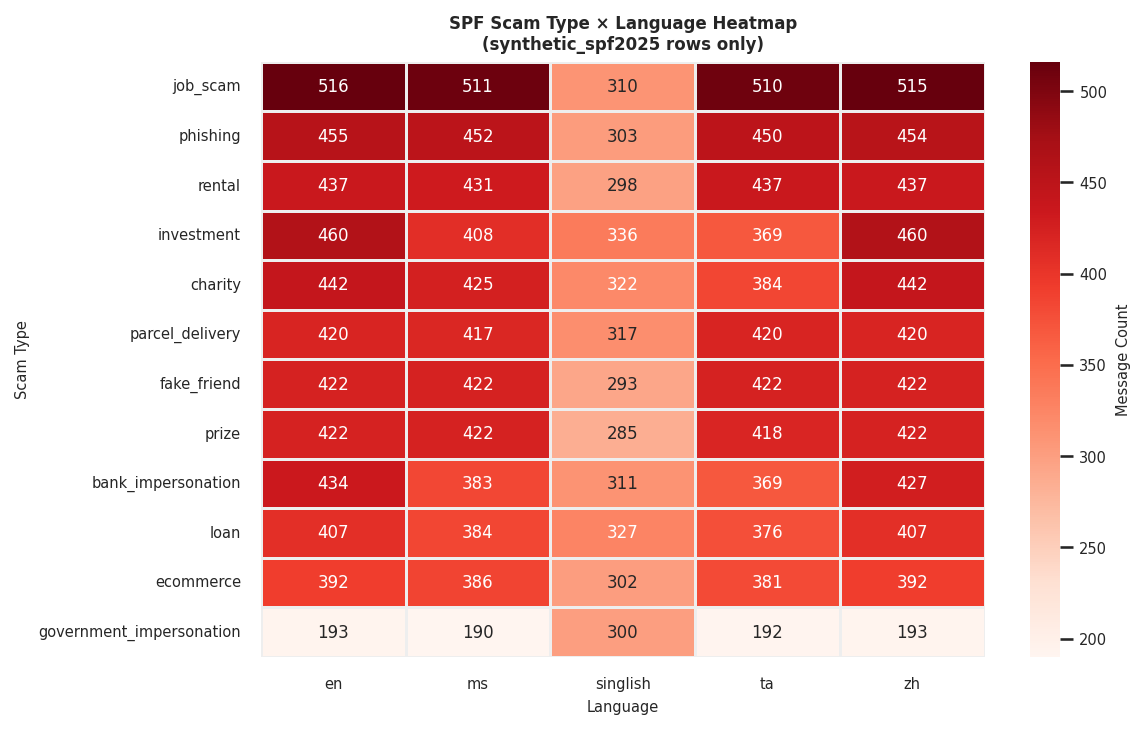

In [75]:
# ── plot 04 · SPF scam type × language heatmap ───────────────────────────────
scam_df = df[df["label"] == 1].copy()
pivot = scam_df.groupby(["scam_type", "language"]).size().unstack(fill_value=0)
spf_types = ["job_scam", "phishing", "rental", "investment", "charity",
             "parcel_delivery", "fake_friend", "prize", "bank_impersonation",
             "loan", "ecommerce", "government_impersonation"]
pivot = pivot.loc[[t for t in spf_types if t in pivot.index]]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True, fmt="d", cmap="Reds",
    linewidths=0.5, linecolor="#eee", ax=ax,
    annot_kws={"size": 8},                      
    cbar_kws={"label": "Message Count"}
)
ax.set_title("SPF Scam Type × Language Heatmap\n(synthetic_spf2025 rows only)",
             fontweight="bold", fontsize=8)
ax.set_xlabel("Language", fontsize=7)
ax.set_ylabel("Scam Type", fontsize=7)
ax.tick_params(axis="x", rotation=0, labelsize=7)
ax.tick_params(axis="y", rotation=0, labelsize=7)
ax.collections[0].colorbar.ax.tick_params(labelsize=7)
ax.collections[0].colorbar.set_label("Message Count", size=7)
plt.tight_layout()
save(fig, "04_scam_type_language_heatmap")
plt.show()

### 3.5 Source Distribution by Language

✓ 05_source_language_breakdown.png


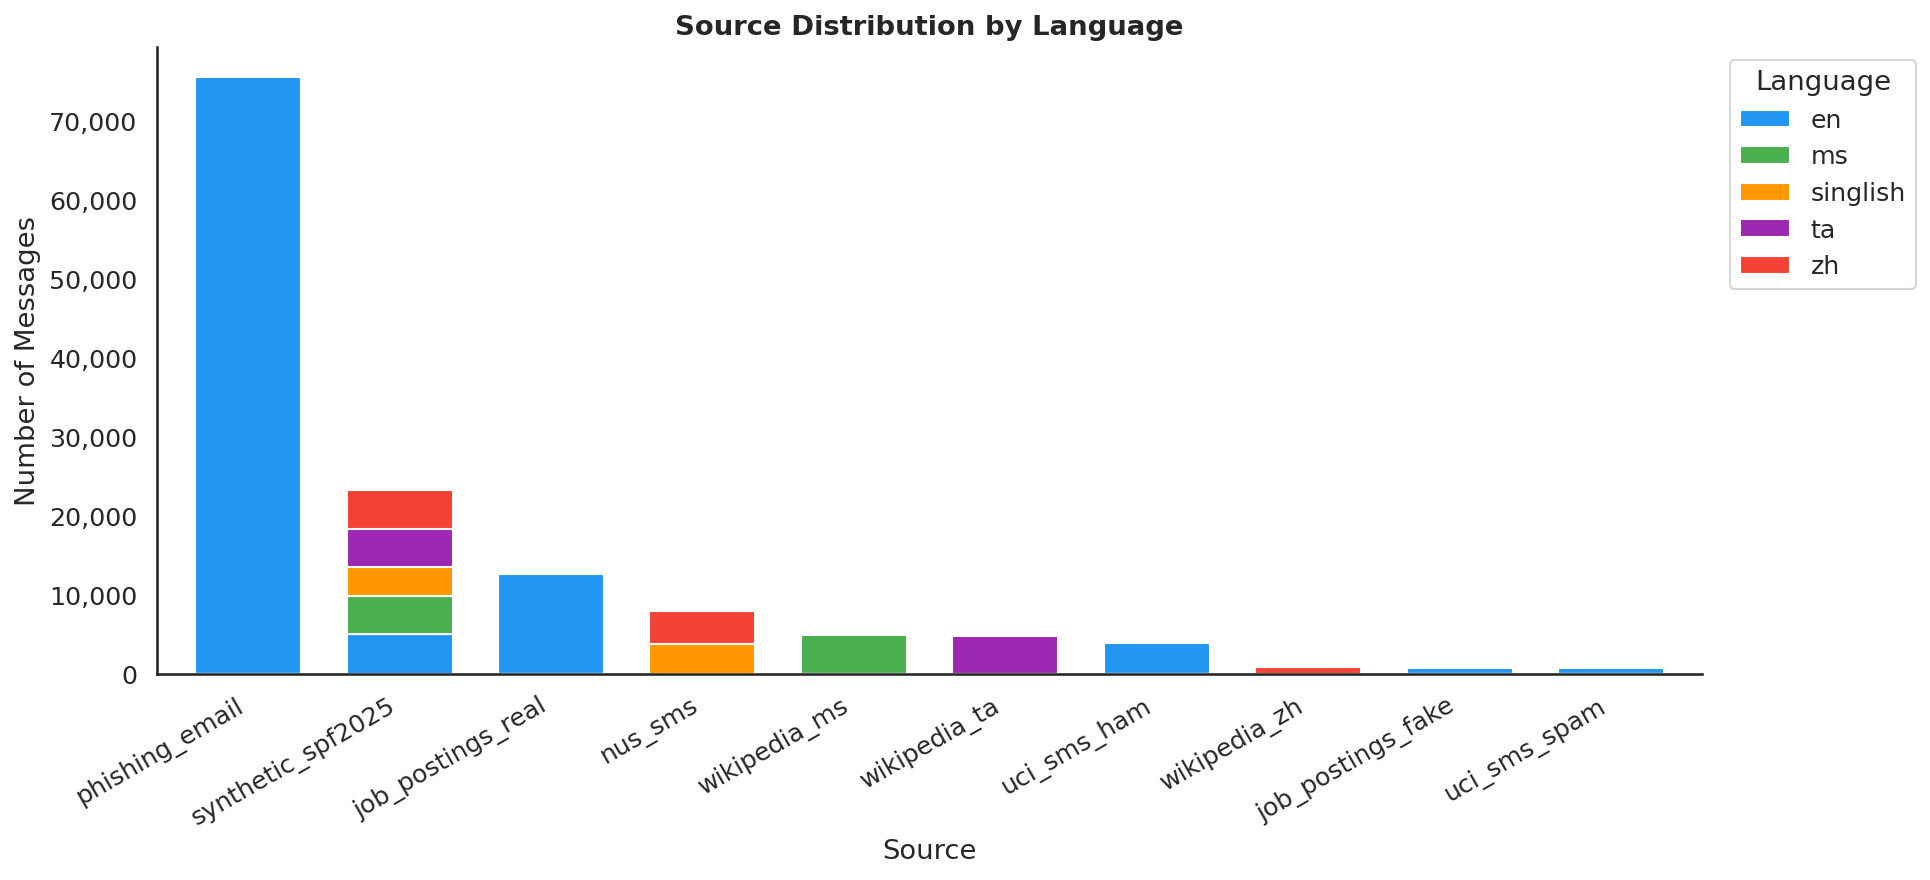

In [72]:
# ── plot 05 · source contribution by language (stacked bar) ──────────────────
src_lang = df.groupby(["source", "language"]).size().unstack(fill_value=0)
src_lang = src_lang.loc[df["source"].value_counts().index]

fig, ax = plt.subplots(figsize=(13, 6))
src_lang.plot(
    kind="bar", stacked=True, ax=ax,
    color=[PALETTE.get(l, "#607D8B") for l in src_lang.columns],
    edgecolor="white", width=0.7
)
ax.set_title("Source Distribution by Language", fontweight="bold")
ax.set_xlabel("Source")
ax.set_ylabel("Number of Messages")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="Language", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
save(fig, "05_source_language_breakdown")
plt.show()

### 3.6 Data quality summary

In [73]:
print("=== DATA QUALITY REPORT ===\n")

# label conflicts — same text with both labels
conflicts = (df.groupby("text")["label"].nunique().reset_index().query("label > 1"))
print(f"1. Label conflicts (same text, different labels): {len(conflicts):,}")

# very short messages
short = df[df["char_len"] < 10]
print(f"2. Very short messages (< 10 chars): {len(short):,}")

# very long messages
long_msgs = df[df["char_len"] > 5000]
print(f"3. Very long messages (> 5,000 chars): {len(long_msgs):,}")
print(f"   Max:         {df['char_len'].max():,} chars")
print(f"   99th pctile: {df['char_len'].quantile(0.99):.0f} chars")

# literal nan strings
nan_str = df[df["text"].str.lower() == "nan"]
print(f"4. Rows with literal nan text: {len(nan_str):,}")

print("\n=== NOTES ===")
print("XLM-RoBERTa max input: 512 tokens. Long messages will be truncated during tokenisation.")
if len(conflicts) > 0:
    print("Review label conflicts before training.")


=== DATA QUALITY REPORT ===

1. Label conflicts (same text, different labels): 0
2. Very short messages (< 10 chars): 1,599
3. Very long messages (> 5,000 chars): 4,687
   Max:         4,279,526 chars
   99th pctile: 11135 chars
4. Rows with literal nan text: 0

=== NOTES ===
XLM-RoBERTa max input: 512 tokens. Long messages will be truncated during tokenisation.


### 3.7 EDA summary table

In [74]:
rows = []
for lang in df["language"].unique():
    sub = df[df["language"] == lang]
    rows.append({
        "language":        lang,
        "total_rows":      len(sub),
        "scam_rows":       int((sub["label"] == 1).sum()),
        "ham_rows":        int((sub["label"] == 0).sum()),
        "balance_ratio":   round((sub["label"] == 1).sum() / len(sub), 3),
        "avg_char_len":    round(sub["char_len"].mean(), 1),
        "median_char_len": round(sub["char_len"].median(), 1),
        "avg_word_count":  round(sub["word_count"].mean(), 1),
    })

summary = pd.DataFrame(rows).sort_values("total_rows", ascending=False)
totals = {
    "language":        "TOTAL",
    "total_rows":      len(df),
    "scam_rows":       int((df["label"] == 1).sum()),
    "ham_rows":        int((df["label"] == 0).sum()),
    "balance_ratio":   round((df["label"] == 1).sum() / len(df), 3),
    "avg_char_len":    round(df["char_len"].mean(), 1),
    "median_char_len": round(df["char_len"].median(), 1),
    "avg_word_count":  round(df["word_count"].mean(), 1),
}
summary = pd.concat([summary, pd.DataFrame([totals])], ignore_index=True)

summary_path = os.path.join(REPORT_DIR, "eda_summary.csv")
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
print("=== EDA SUMMARY ===")
print(summary.to_string(index=False))
print(f"\nSaved: {summary_path}")

print("\nFigures in reports/figures/:")
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f"  {f}")

print("\nNB02 complete.")


=== EDA SUMMARY ===
language  total_rows  scam_rows  ham_rows  balance_ratio  avg_char_len  median_char_len  avg_word_count
      en       98310      49155     49155            0.5        1159.9            533.0           146.9
      zh        9982       4991      4991            0.5         363.6             28.0            11.4
      ms        9662       4831      4831            0.5        2187.3            139.0           297.9
      ta        9456       4728      4728            0.5        2049.7            150.0           225.8
singlish        7408       3704      3704            0.5          55.6             54.0            10.7
   TOTAL      134818      67409     67409            0.5        1176.3            388.0           145.7

Saved: /kaggle/working/reports/eda_summary.csv

Figures in reports/figures/:

NB02 complete.
